In [45]:
# IMPORT REQUIRED LIBRARIES
# Data Handling
import pandas as pd
import numpy as np
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Text Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
# Save Model
import joblib
# Word Cloud
from wordcloud import WordCloud
# Download NLTK Resources
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
# STEP 4 : LOAD THE DATASET
# Load Fake News Dataset
fake_df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Fake_News_Detection\Fake.csv")
# Load True News Dataset
true_df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Fake_News_Detection\True.csv")
print("Fake News Dataset")
display(fake_df.head())
print("True News Dataset")
display(true_df.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


True News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [28]:
import os
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\DELL


In [29]:
import os
print("Notebook is running from:")
print(os.getcwd())
print("\nFiles in this folder:")
print(os.listdir())

Notebook is running from:
C:\Users\DELL

Files in this folder:
['.android', '.arduinoIDE', '.BigNox', '.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.m2', '.python_history', '.streamlit', '.vscode', '.vscode-shared', '3D Objects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'd4ac4633ebd6440fa397b84f1bc94a3c.7z', 'Documents', 'Downloads', 'Fake_News_Detection.ipynb', 'fake_news_model.pkl', 'Favorites', 'feature_names.pkl', 'IdeaProjects', 'inittk.ini', 'inst.ini', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'Nox_share', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9829b8c5-4ff6-11ec-9c42-8c219cbcc45f}.TM.blf', 'NTUSER.DAT{9829b8c5-4ff6-11ec-9c42-8c219cbcc45f}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{9829b8c5-4ff6-11ec-9c42-8c219cbcc45f}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'nuuid.ini', 'OneDrive', 'prediction_results.csv

In [30]:
import os
print(os.getcwd())
print(os.path.abspath("Fake_News_Detection.ipynb"))

C:\Users\DELL
C:\Users\DELL\Fake_News_Detection.ipynb


In [31]:
# STEP 5 : EXPLORATORY DATA ANALYSIS (EDA)
print("========== DATASET SHAPE ==========")
print("Fake Dataset Shape :", fake_df.shape)
print("True Dataset Shape :", true_df.shape)
print("\n========== COLUMN NAMES ==========")
print("Fake Dataset Columns:")
print(fake_df.columns)
print("\nTrue Dataset Columns:")
print(true_df.columns)
print("\n========== DATASET INFORMATION ==========")
print("\nFake Dataset Info:")
fake_df.info()
print("\nTrue Dataset Info:")
true_df.info()
print("\n========== MISSING VALUES ==========")
print("\nMissing Values in Fake Dataset:")
print(fake_df.isnull().sum())
print("\nMissing Values in True Dataset:")
print(true_df.isnull().sum())

========== DATASET SHAPE ==========
Fake Dataset Shape : (23481, 4)
True Dataset Shape : (21417, 4)

========== COLUMN NAMES ==========
Fake Dataset Columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')

True Dataset Columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')

========== DATASET INFORMATION ==========

Fake Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB

True Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  s

In [32]:
# BASIC STATISTICS
print("Fake News Dataset Statistics")
display(fake_df.describe(include='all'))
print("True News Dataset Statistics")
display(true_df.describe(include='all'))

Fake News Dataset Statistics


,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


True News Dataset Statistics


,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [33]:
# STEP 6 : MERGE THE DATASETS
# Add labels
fake_df["label"] = 0   # Fake News
true_df["label"] = 1   # True News
# Combine both datasets
news_df = pd.concat([fake_df, true_df], ignore_index=True)
# Shuffle the dataset
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)
# Display first 5 rows
print("Combined Dataset")
display(news_df.head())

Combined Dataset


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [34]:
# CHECK DATASET
print("Combined Dataset Shape:", news_df.shape)
print("\nLabel Distribution:")
print(news_df["label"].value_counts())

Combined Dataset Shape: (44898, 5)

Label Distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [35]:
# STEP 7 : TEXT PREPROCESSING
import re
import string
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
def preprocess_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords (No stemming)
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

In [36]:
# APPLY PREPROCESSING
news_df["text"] = news_df["text"].fillna("")
news_df["clean_text"] = news_df["text"].apply(preprocess_text)
print("Preprocessing Completed Successfully!")
news_df[["text", "clean_text"]].head()

Preprocessing Completed Successfully!


,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire says ben stein reputable profe...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters us president donald trump r...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters us presidential candi...


In [37]:
# STEP 8 : TF-IDF VECTORIZATION
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
# Transform the cleaned text
X = tfidf.fit_transform(news_df["clean_text"])
# Target labels
y = news_df["label"]
print("TF-IDF Vectorization Completed!")
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

TF-IDF Vectorization Completed!
Feature Matrix Shape: (44898, 5000)
Target Shape: (44898,)


In [38]:
# Display first 20 feature names
feature_names = tfidf.get_feature_names_out()
print("First 20 TF-IDF Features:")
print(feature_names[:20])

First 20 TF-IDF Features:
['abandon' 'abandoned' 'abbas' 'abc' 'abdullah' 'abe' 'abedin' 'ability'
 'able' 'abortion' 'abortions' 'abroad' 'absence' 'absolute' 'absolutely'
 'absurd' 'abu' 'abuse' 'abuses' 'academic']


In [39]:
# STEP 9 : TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Train-Test Split Completed!")
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Train-Test Split Completed!
Training Features : (35918, 5000)
Testing Features  : (8980, 5000)
Training Labels   : (35918,)
Testing Labels    : (8980,)


In [40]:
# STEP 10 : TRAIN LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
# Create the model
model = LogisticRegression(max_iter=1000)
# Train the model
model.fit(X_train, y_train)
print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [41]:
# STEP 11 : MODEL EVALUATION
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Make predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy :", round(accuracy * 100, 2), "%")
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Model Accuracy : 98.71 %

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Confusion Matrix
[[4634   76]
 [  40 4230]]


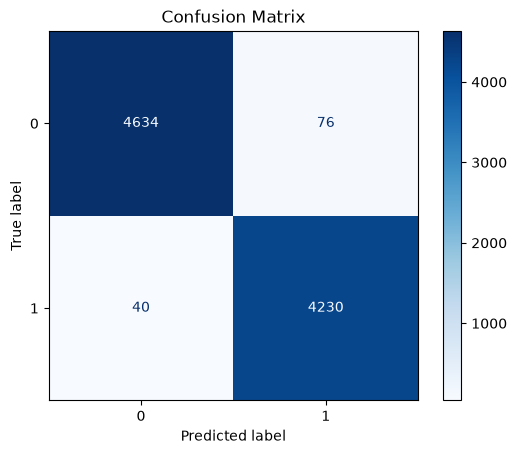

In [42]:
# STEP 12 : CONFUSION MATRIX VISUALIZATION
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()

In [43]:
# STEP 13 : CUSTOM NEWS PREDICTION
news = input("Enter a news article: ")
# Preprocess
clean_news = preprocess_text(news)
# Convert to TF-IDF
news_vector = tfidf.transform([clean_news])
# Predict
prediction = model.predict(news_vector)
if prediction[0] == 1:
    print("\nPrediction: ✅ REAL NEWS")
else:
    print("\nPrediction: ❌ FAKE NEWS")

Enter a news article:  Government has introduced any Educational schemes to students



Prediction: ❌ FAKE NEWS


In [44]:
# STEP 14 : SAVE MODEL
import joblib
joblib.dump(model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Model saved successfully!")

Model saved successfully!
